<a href="https://colab.research.google.com/github/akshitasankhwar/pwdatascience/blob/master/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unsupervised Learning & Clustering – Answers

## 1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where algorithms learn patterns from data **without labeled outputs**. The model tries to identify hidden structures or relationships within the dataset. Common tasks include clustering, association rule learning, and dimensionality reduction. Unlike supervised learning, the algorithm does not have predefined categories or targets.

---

## 2. How does K-Means clustering algorithm work?

K-Means is a clustering algorithm that groups data points into **K clusters** based on similarity.  
Steps:
1. Choose the number of clusters (K).
2. Randomly initialize K cluster centroids.
3. Assign each data point to the nearest centroid.
4. Recalculate centroids as the mean of all points in that cluster.
5. Repeat steps 3 and 4 until cluster assignments stop changing.

The goal is to minimize the distance between points and their cluster centroid.

---

## 3. Explain the concept of a dendrogram in hierarchical clustering.

A dendrogram is a **tree-like diagram** used to visualize hierarchical clustering results. It shows how clusters are formed by progressively merging or splitting groups of data points. The height of the branches represents the distance or dissimilarity between clusters. It helps determine the optimal number of clusters by cutting the tree at a certain level.

---

## 4. What is the main difference between K-Means and Hierarchical Clustering?

K-Means requires specifying the number of clusters in advance and partitions data into clusters based on centroid distance. Hierarchical clustering builds a hierarchy of clusters either by merging smaller clusters (agglomerative) or splitting larger clusters (divisive). Unlike K-Means, hierarchical clustering does not require specifying the number of clusters beforehand.

---

## 5. What are the advantages of DBSCAN over K-Means?

DBSCAN can detect clusters of **arbitrary shapes**, while K-Means assumes spherical clusters. It can also identify **noise and outliers**, which K-Means cannot. Additionally, DBSCAN does not require specifying the number of clusters beforehand.

---

## 6. When would you use Silhouette Score in clustering?

Silhouette Score is used to evaluate how well clusters are formed. It measures how similar a data point is to its own cluster compared to other clusters. It is useful for determining the **optimal number of clusters** and assessing clustering quality.

---

## 7. What are the limitations of Hierarchical Clustering?

Hierarchical clustering is computationally expensive for large datasets. It has **high time complexity**, making it less suitable for very large data. Once clusters are merged or split, the decision cannot be undone, which may lead to incorrect cluster structures.

---

## 8. Why is feature scaling important in clustering algorithms like K-Means?

K-Means uses **distance calculations** such as Euclidean distance. If features have different scales, larger values can dominate the distance calculation and bias the clustering results. Feature scaling ensures all variables contribute equally.

---

## 9. How does DBSCAN identify noise points?

DBSCAN identifies noise points as data points that do not belong to any dense cluster. If a point does not have enough neighboring points within a specified radius (epsilon), it is labeled as a noise or outlier point.

---

## 10. Define inertia in the context of K-Means.

Inertia is the **sum of squared distances** between each data point and the centroid of its assigned cluster. It measures how tightly the data points are grouped within clusters. Lower inertia indicates better clustering.

---

## 11. What is the elbow method in K-Means clustering?

The elbow method is used to determine the optimal number of clusters (K). It plots inertia against different values of K. The point where the decrease in inertia slows down significantly (forming an elbow shape) is considered the optimal K.

---

## 12. Describe the concept of "density" in DBSCAN.

In DBSCAN, density refers to the concentration of data points within a given region. A cluster is formed when a group of points lies within a specified radius and meets the minimum number of neighboring points required.

---

## 13. Can hierarchical clustering be used on categorical data?

Yes, hierarchical clustering can be applied to categorical data if an appropriate **distance or similarity measure** is used, such as Hamming distance or other categorical similarity metrics.

---

## 14. What does a negative Silhouette Score indicate?

A negative Silhouette Score indicates that data points may have been assigned to the wrong cluster. It means the point is closer to another cluster than to the cluster it currently belongs to.

---

## 15. Explain the term "linkage criteria" in hierarchical clustering.

Linkage criteria determine how the distance between clusters is calculated when merging them. Common linkage methods include single linkage, complete linkage, average linkage, and Ward’s method.

---

## 16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

K-Means assumes clusters are spherical and of similar size. If clusters vary significantly in size, density, or shape, K-Means may incorrectly assign points and produce inaccurate clustering results.

---

## 17. What are the core parameters in DBSCAN, and how do they influence clustering?

The two main parameters are:
- **Epsilon (eps):** the radius within which neighboring points are searched.
- **MinPts:** the minimum number of points required to form a dense region.

These parameters control how clusters are formed and how noise points are identified.

---

## 18. How does K-Means++ improve upon standard K-Means initialization?

K-Means++ improves centroid initialization by choosing starting points that are far apart. This reduces the chances of poor cluster initialization and improves convergence speed and clustering accuracy.

---

## 19. What is agglomerative clustering?

Agglomerative clustering is a **bottom-up hierarchical clustering method**. Each data point starts as its own cluster, and clusters are gradually merged based on similarity until all points belong to a single cluster or a stopping condition is reached.

---

## 20. What makes Silhouette Score a better metric than just inertia for model evaluation?

Inertia only measures how tightly points are grouped within clusters, but it does not evaluate how well clusters are separated. Silhouette Score considers both **intra-cluster cohesion and inter-cluster separation**, making it a more reliable metric for evaluating clustering quality.

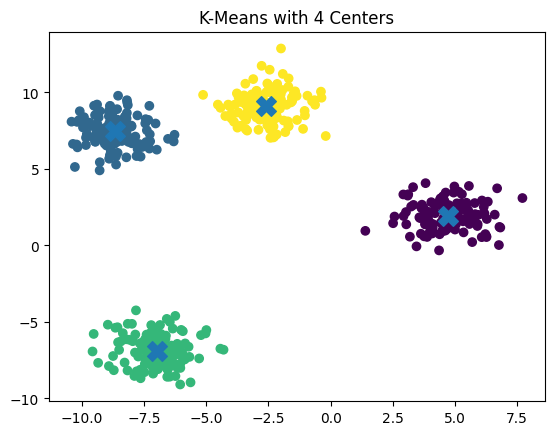

In [1]:
# Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering.
# Visualize using a scatter plot.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=500, centers=4, random_state=42)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=200)
plt.title("K-Means with 4 Centers")
plt.show()

In [ ]:
# Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters.
# Display the first 10 predicted labels.

from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
X = iris.data

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X)

print(labels[:10])

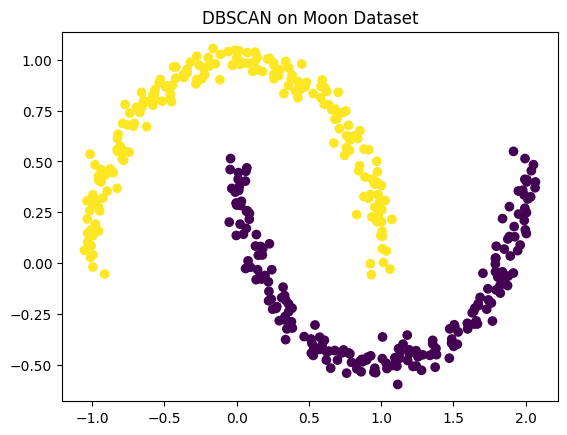

In [2]:
# Generate synthetic data using make_moons and apply DBSCAN.
# Highlight outliers in the plot.

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_moons(n_samples=400, noise=0.05)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN on Moon Dataset")
plt.show()

In [3]:
# Load the Wine dataset and apply K-Means clustering after standardizing the features.
# Print the size of each cluster.

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X)

unique, counts = np.unique(labels, return_counts=True)

for i, c in zip(unique, counts):
    print("Cluster", i, "size:", c)

Cluster 0 size: 65
Cluster 1 size: 51
Cluster 2 size: 62


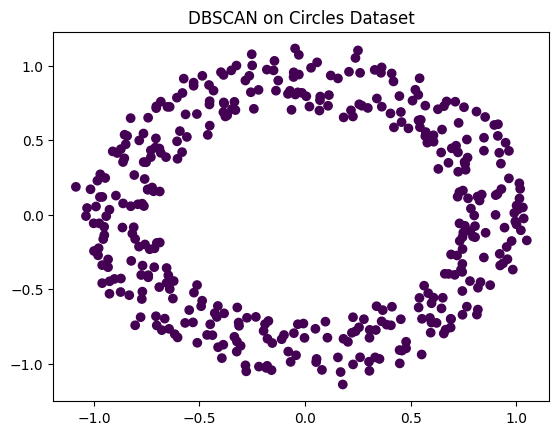

In [4]:
# Use make_circles to generate synthetic data and cluster it using DBSCAN.
# Plot the result.

from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_circles(n_samples=400, noise=0.05)

db = DBSCAN(eps=0.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN on Circles Dataset")
plt.show()

In [5]:
# Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters.
# Output the cluster centroids.

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

data = load_breast_cancer()
X = MinMaxScaler().fit_transform(data.data)

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X)

print("Cluster Centroids:")
print(kmeans.cluster_centers_)

Cluster Centroids:
[[0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]
 [0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]]


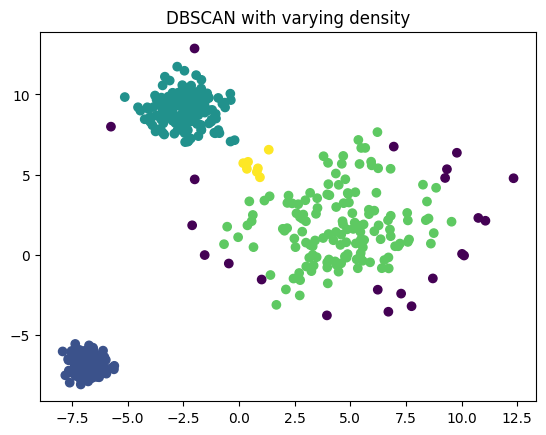

In [6]:
# Generate synthetic data using make_blobs with varying cluster standard deviations
# and cluster with DBSCAN.

from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=500, centers=3, cluster_std=[1.0,2.5,0.5], random_state=42)

db = DBSCAN(eps=1.2, min_samples=5)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN with varying density")
plt.show()

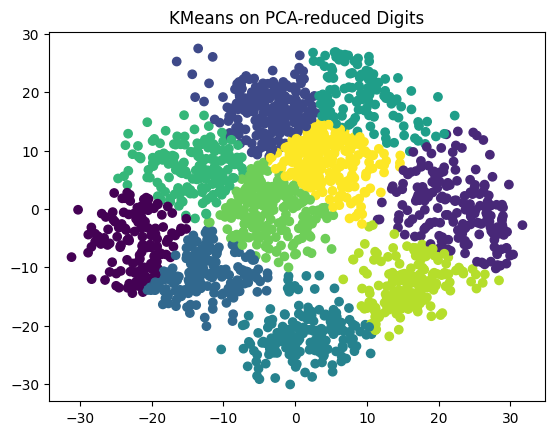

In [7]:
# Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

digits = load_digits()

pca = PCA(n_components=2)
X = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("KMeans on PCA-reduced Digits")
plt.show()

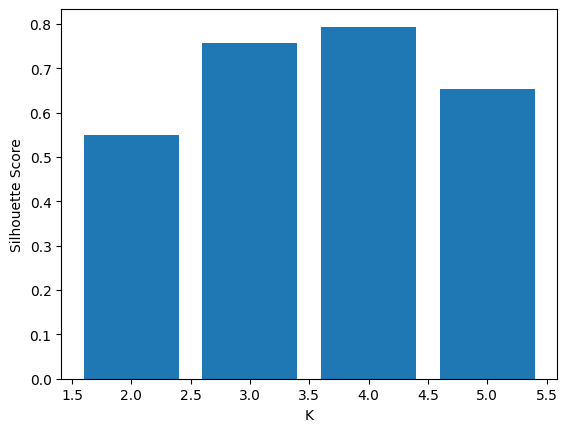

In [8]:
# Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5.
# Display as a bar chart.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X,_ = make_blobs(n_samples=400, centers=4, random_state=42)

scores = []
ks = range(2,6)

for k in ks:
    labels = KMeans(n_clusters=k).fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.bar(ks, scores)
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

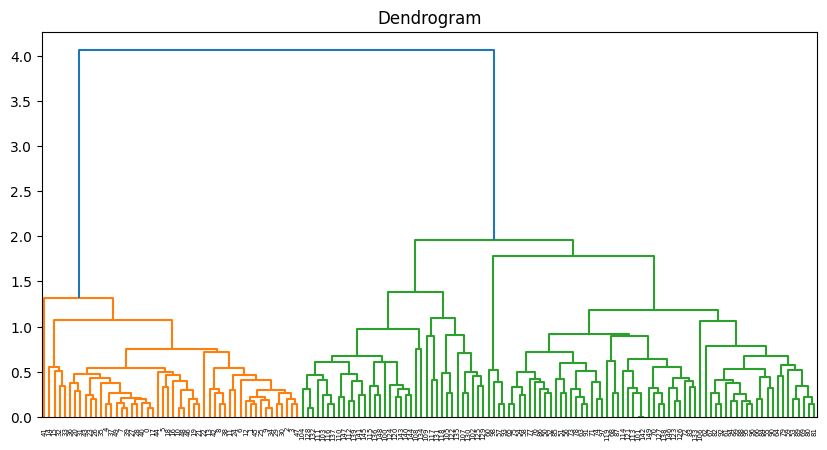

In [9]:
# Load the Iris dataset and use hierarchical clustering to group data.
# Plot a dendrogram with average linkage.

from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

iris = load_iris()
Z = linkage(iris.data, method='average')

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Dendrogram")
plt.show()

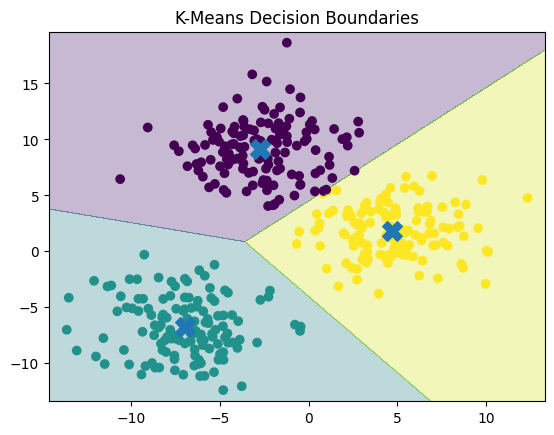

In [10]:
# Generate synthetic data with overlapping clusters using make_blobs,
# then apply K-Means and visualize with decision boundaries.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

X, _ = make_blobs(n_samples=400, centers=3, cluster_std=2.5, random_state=42)

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)

h = 0.02
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=200)
plt.title("K-Means Decision Boundaries")
plt.show()


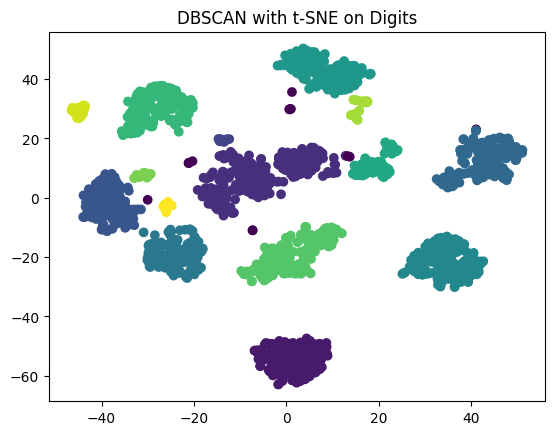

In [11]:
# Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE.
# Visualize the results.

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

digits = load_digits()

X = TSNE(n_components=2, random_state=42).fit_transform(digits.data)

db = DBSCAN(eps=3)
labels = db.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("DBSCAN with t-SNE on Digits")
plt.show()

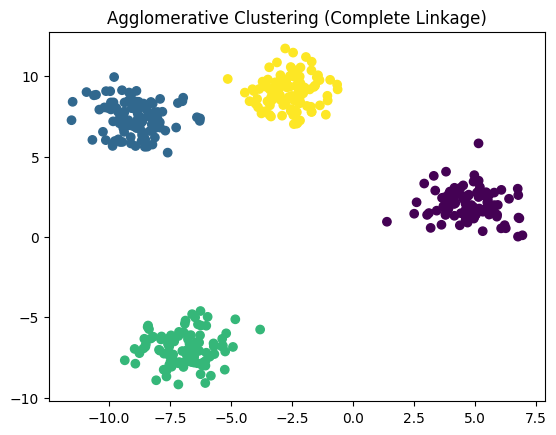

In [12]:
# Generate synthetic data using make_blobs and apply Agglomerative Clustering
# with complete linkage. Plot the result.

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X,_ = make_blobs(n_samples=400, centers=4, random_state=42)

model = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

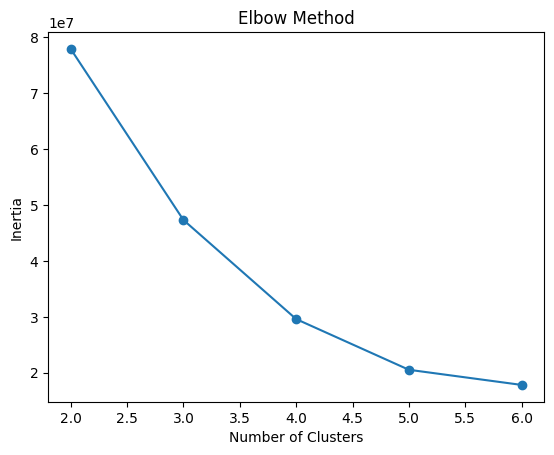

In [13]:
# Load the Breast Cancer dataset and compare inertia values for K = 2 to 6
# using K-Means. Show results in a line plot.

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data

inertia = []
K = range(2,7)

for k in K:
    model = KMeans(n_clusters=k)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

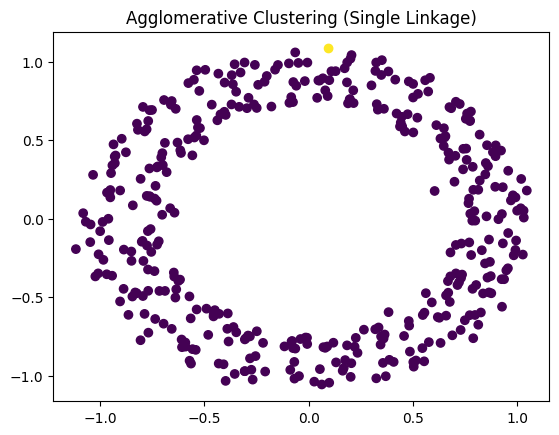

In [14]:
# Generate synthetic concentric circles using make_circles and cluster
# using Agglomerative Clustering with single linkage.

from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X,_ = make_circles(n_samples=400, noise=0.05)

model = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Single Linkage)")
plt.show()

In [15]:
# Use the Wine dataset, apply DBSCAN after scaling the data,
# and count the number of clusters (excluding noise).

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)

db = DBSCAN(eps=1.5, min_samples=5)
labels = db.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)

print("Number of clusters:", clusters)

Number of clusters: 0


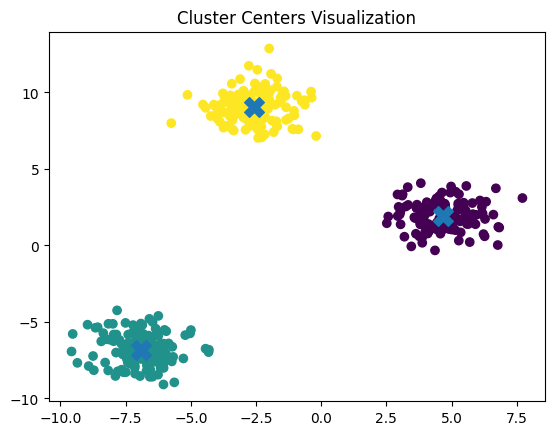

In [16]:
# Generate synthetic data with make_blobs and apply KMeans.
# Then plot the cluster centers on top of the data points.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X,_ = make_blobs(n_samples=400, centers=3, random_state=42)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='X', s=200)
plt.title("Cluster Centers Visualization")
plt.show()

In [17]:
# Load the Iris dataset, cluster with DBSCAN,
# and print how many samples were identified as noise.

from sklearn.datasets import load_iris
from sklearn.cluster import DBSCAN

iris = load_iris()
X = iris.data

db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

noise = list(labels).count(-1)

print("Number of noise samples:", noise)

Number of noise samples: 17


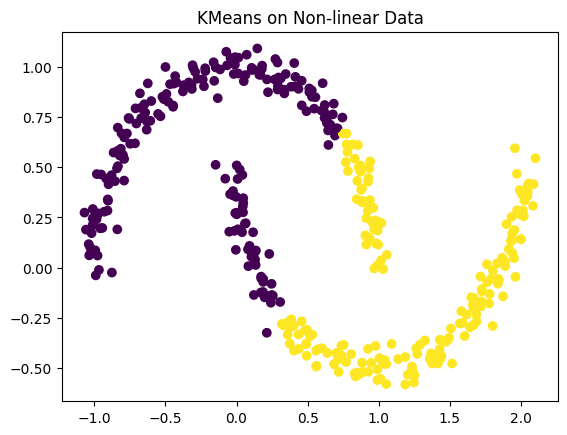

In [18]:
# Generate synthetic non-linearly separable data using make_moons,
# apply K-Means, and visualize the clustering result.

from sklearn.datasets import make_moons
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X,_ = make_moons(n_samples=400, noise=0.05)

kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("KMeans on Non-linear Data")
plt.show()

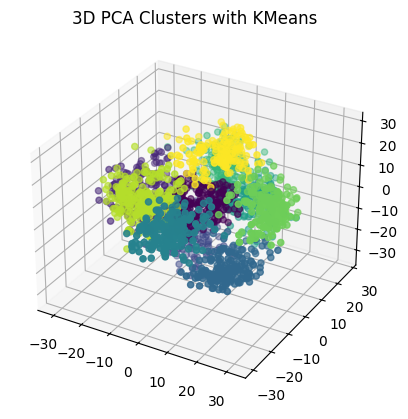

In [19]:
# Load the Digits dataset, apply PCA to reduce to 3 components,
# then use KMeans and visualize with a 3D scatter plot.

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

digits = load_digits()

pca = PCA(n_components=3)
X = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10)
labels = kmeans.fit_predict(X)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], X[:,2], c=labels)
ax.set_title("3D PCA Clusters with KMeans")

plt.show()

In [20]:
# Generate synthetic blobs with 5 centers and apply KMeans.
# Then use silhouette_score to evaluate the clustering.

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=5, random_state=42)

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)

score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.678738720085253


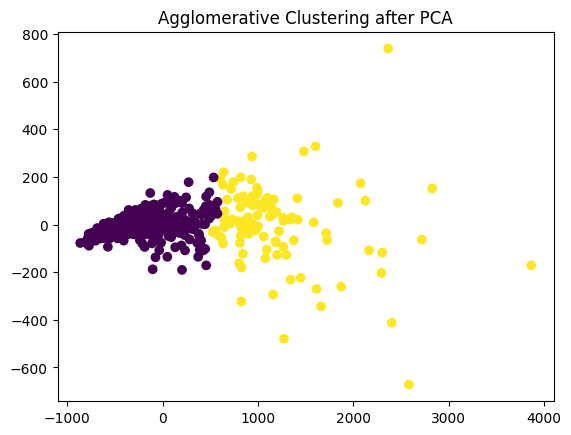

In [21]:
# Load the Breast Cancer dataset, reduce dimensionality using PCA,
# and apply Agglomerative Clustering. Visualize in 2D.

from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

data = load_breast_cancer()

pca = PCA(n_components=2)
X = pca.fit_transform(data.data)

model = AgglomerativeClustering(n_clusters=2)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering after PCA")
plt.show()

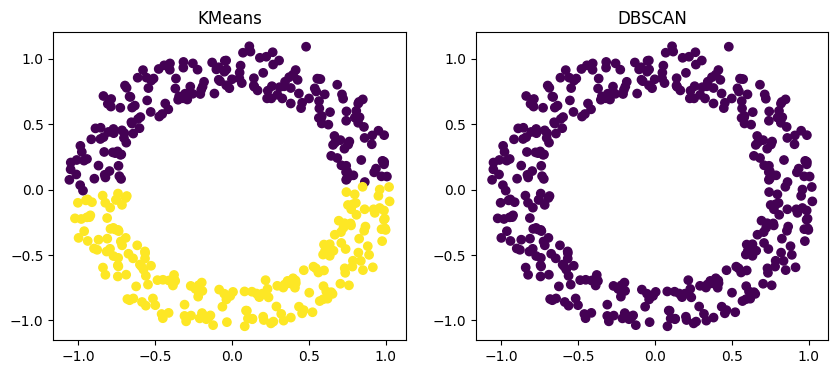

In [22]:
# Generate noisy circular data using make_circles and visualize clustering
# results from KMeans and DBSCAN side-by-side.

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt

X,_ = make_circles(n_samples=400, noise=0.05)

kmeans = KMeans(n_clusters=2)
k_labels = kmeans.fit_predict(X)

db = DBSCAN(eps=0.2)
d_labels = db.fit_predict(X)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c=k_labels)
plt.title("KMeans")

plt.subplot(1,2,2)
plt.scatter(X[:,0], X[:,1], c=d_labels)
plt.title("DBSCAN")

plt.show()

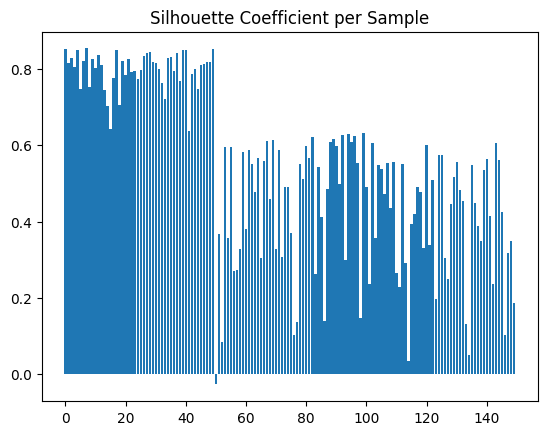

In [23]:
# Load the Iris dataset and plot the Silhouette Coefficient
# for each sample after KMeans clustering.

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X)

scores = silhouette_samples(X, labels)

plt.bar(range(len(scores)), scores)
plt.title("Silhouette Coefficient per Sample")
plt.show()

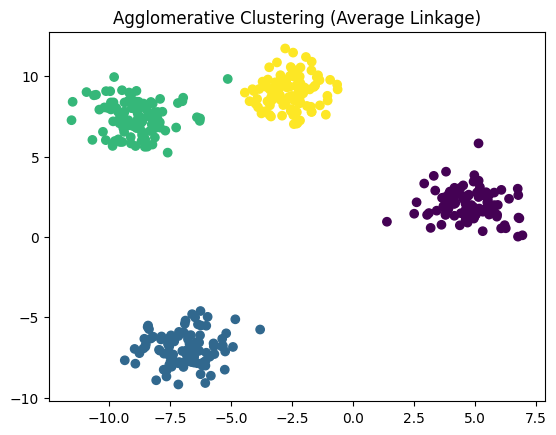

In [24]:
# Generate synthetic data using make_blobs and apply Agglomerative Clustering
# with 'average' linkage. Visualize clusters.

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X,_ = make_blobs(n_samples=400, centers=4, random_state=42)

model = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

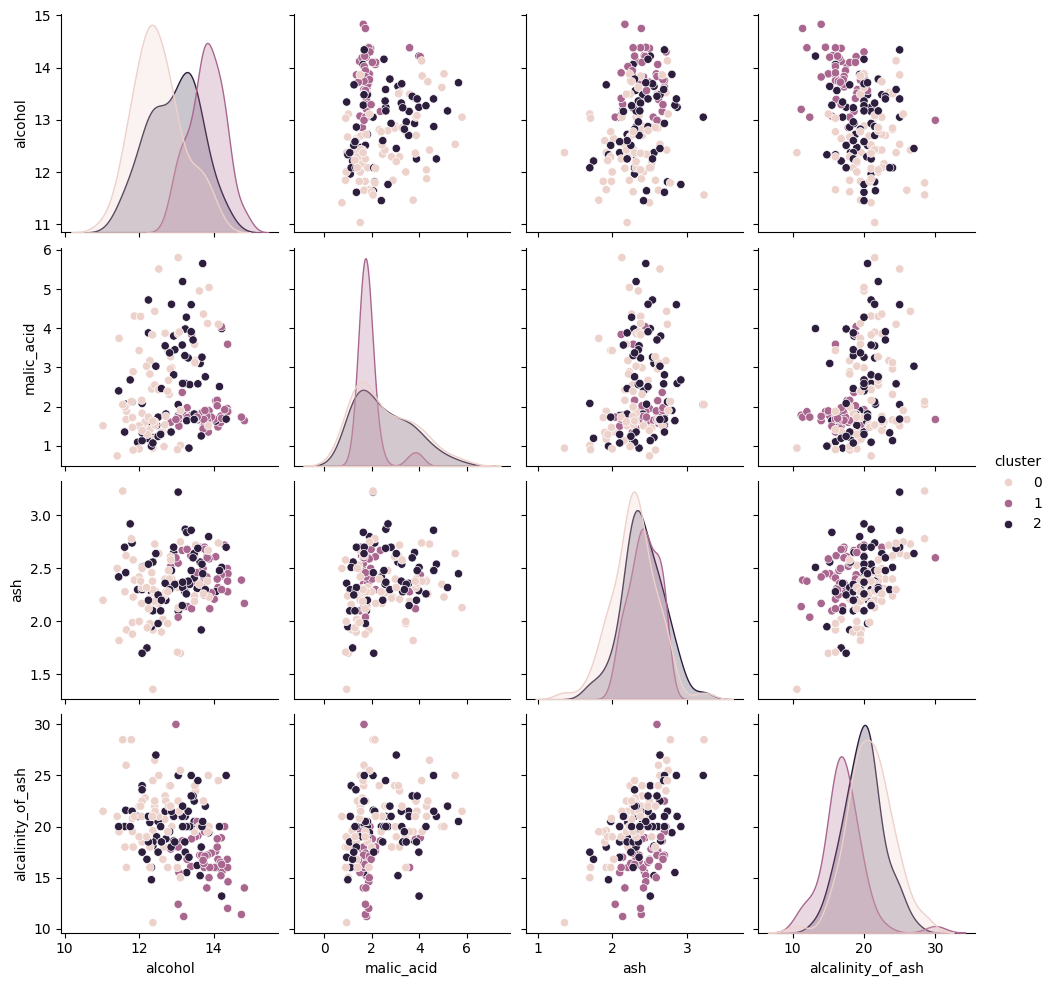

In [25]:
# Load the Wine dataset, apply KMeans, and visualize the cluster assignments
# in a seaborn pairplot (first 4 features).

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(df)

df['cluster'] = labels

sns.pairplot(df.iloc[:,:4].assign(cluster=labels), hue='cluster')
plt.show()

In [26]:
# Generate noisy blobs using make_blobs and use DBSCAN to identify
# both clusters and noise points. Print the count.

from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

X,_ = make_blobs(n_samples=400, centers=3, cluster_std=1.5, random_state=42)

db = DBSCAN(eps=1.0, min_samples=5)
labels = db.fit_predict(X)

clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = list(labels).count(-1)

print("Number of clusters:", clusters)
print("Number of noise points:", noise)

Number of clusters: 3
Number of noise points: 29


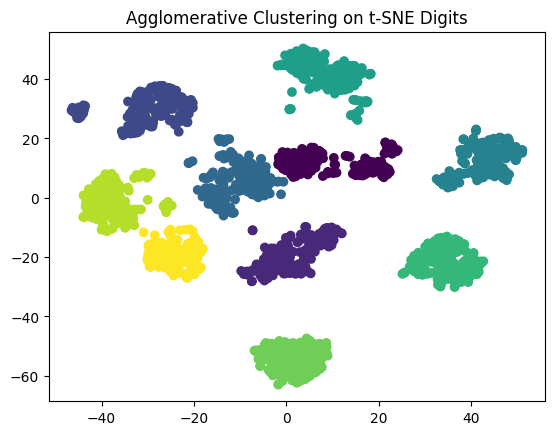

In [27]:
# Load the Digits dataset, reduce dimensions using t-SNE,
# then apply Agglomerative Clustering and plot the clusters.

from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

digits = load_digits()

X = TSNE(n_components=2, random_state=42).fit_transform(digits.data)

model = AgglomerativeClustering(n_clusters=10)
labels = model.fit_predict(X)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Agglomerative Clustering on t-SNE Digits")
plt.show()